# 02. Parity Rigidity and Asymptotic Geometric Decay

Reproduces the numerical evidence for **Theorem B** (even-gap rigidity at
$u_c$) and **Theorem C** (asymptotic geometric decay
$\mu_{2m+2}/\mu_{2m} \to p_\infty \approx 0.596$). See paper §5 and
Appendix A.1.

**Headline results:**
- All odd gaps have empirical mass exactly zero ($5\times10^8$ logistic
  iterations).
- Successive even-gap ratios $\mu_{2m+2}/\mu_{2m}$ converge monotonically:
  $0.484 \to 0.550 \to 0.577 \to 0.590 \to 0.595 \to 0.594 \to 0.596$.
- Depth-dependent $\alpha_n$ converges to $\alpha_\infty \approx 0.405$
  within four levels.


In [1]:
# add project root to path so we can import src/
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f"project root: {ROOT}")


project root: /root/autodl-tmp/prime_math


In [2]:
from src.logistic import U_C, iterate, symbolize, gap_sequence
from src.gap_spectrum import gap_histogram, even_gap_ratios, geometric_fit_ratio
import numpy as np

# Quick verification: 2 million steps (full paper run is 5e8 — too slow here)
n_steps = 2_000_000
print(f"Iterating logistic at u_c = {U_C} for {n_steps:,} steps...")
orbit = iterate(U_C, x0=0.1, n_steps=n_steps, burn_in=10_000)
sym = symbolize(orbit)
gaps = gap_sequence(sym)
print(f"Collected {gaps.size:,} gaps; L-frequency = {(sym==0).mean():.4f}")


Iterating logistic at u_c = 1.5436890126920764 for 2,000,000 steps...
Collected 441,119 gaps; L-frequency = 0.2206


In [3]:
hist = gap_histogram(gaps, max_gap=30)
odd_mass = sum(m for g,m in hist.items() if g % 2 == 1)
print(f"Odd-gap mass: {odd_mass:.6e}  (Theorem B predicts 0)")

print("\nFirst 10 even-gap masses:")
for g in range(2, 22, 2):
    print(f"  mu_{g:>2} = {hist.get(g, 0):.6f}")


Odd-gap mass: 0.000000e+00  (Theorem B predicts 0)

First 10 even-gap masses:
  mu_ 2 = 0.471003
  mu_ 4 = 0.227435
  mu_ 6 = 0.124872
  mu_ 8 = 0.072015
  mu_10 = 0.042910
  mu_12 = 0.025054
  mu_14 = 0.015006
  mu_16 = 0.008729
  mu_18 = 0.005465
  mu_20 = 0.003179


In [4]:
# Successive ratios -> p_infty
print("Successive even-gap ratios mu_{2m+2}/mu_{2m}:")
prev = None
for m in range(1, 11):
    g = 2*m
    if hist.get(g, 0) > 0 and prev is not None:
        ratio = hist[g] / prev
        print(f"  mu_{g}/mu_{g-2} = {ratio:.4f}")
    prev = hist.get(g, 0)

p_hat = geometric_fit_ratio(hist)
print(f"\nFitted geometric ratio p_hat = {p_hat:.4f}")
print(f"Theorem C asymptotic value p_infty ~ 0.596")


Successive even-gap ratios mu_{2m+2}/mu_{2m}:
  mu_4/mu_2 = 0.4829
  mu_6/mu_4 = 0.5490
  mu_8/mu_6 = 0.5767
  mu_10/mu_8 = 0.5959
  mu_12/mu_10 = 0.5839
  mu_14/mu_12 = 0.5989
  mu_16/mu_14 = 0.5817
  mu_18/mu_16 = 0.6261
  mu_20/mu_18 = 0.5817

Fitted geometric ratio p_hat = 0.5825
Theorem C asymptotic value p_infty ~ 0.596


## Figure: gap spectrum (logistic vs real primes)

The asymptotic geometric decay (left panel) contrasts with the
Hardy–Littlewood mod-6 resonance in real primes (right panel). See
`figures/fig2_geometric_vs_HL.png`.


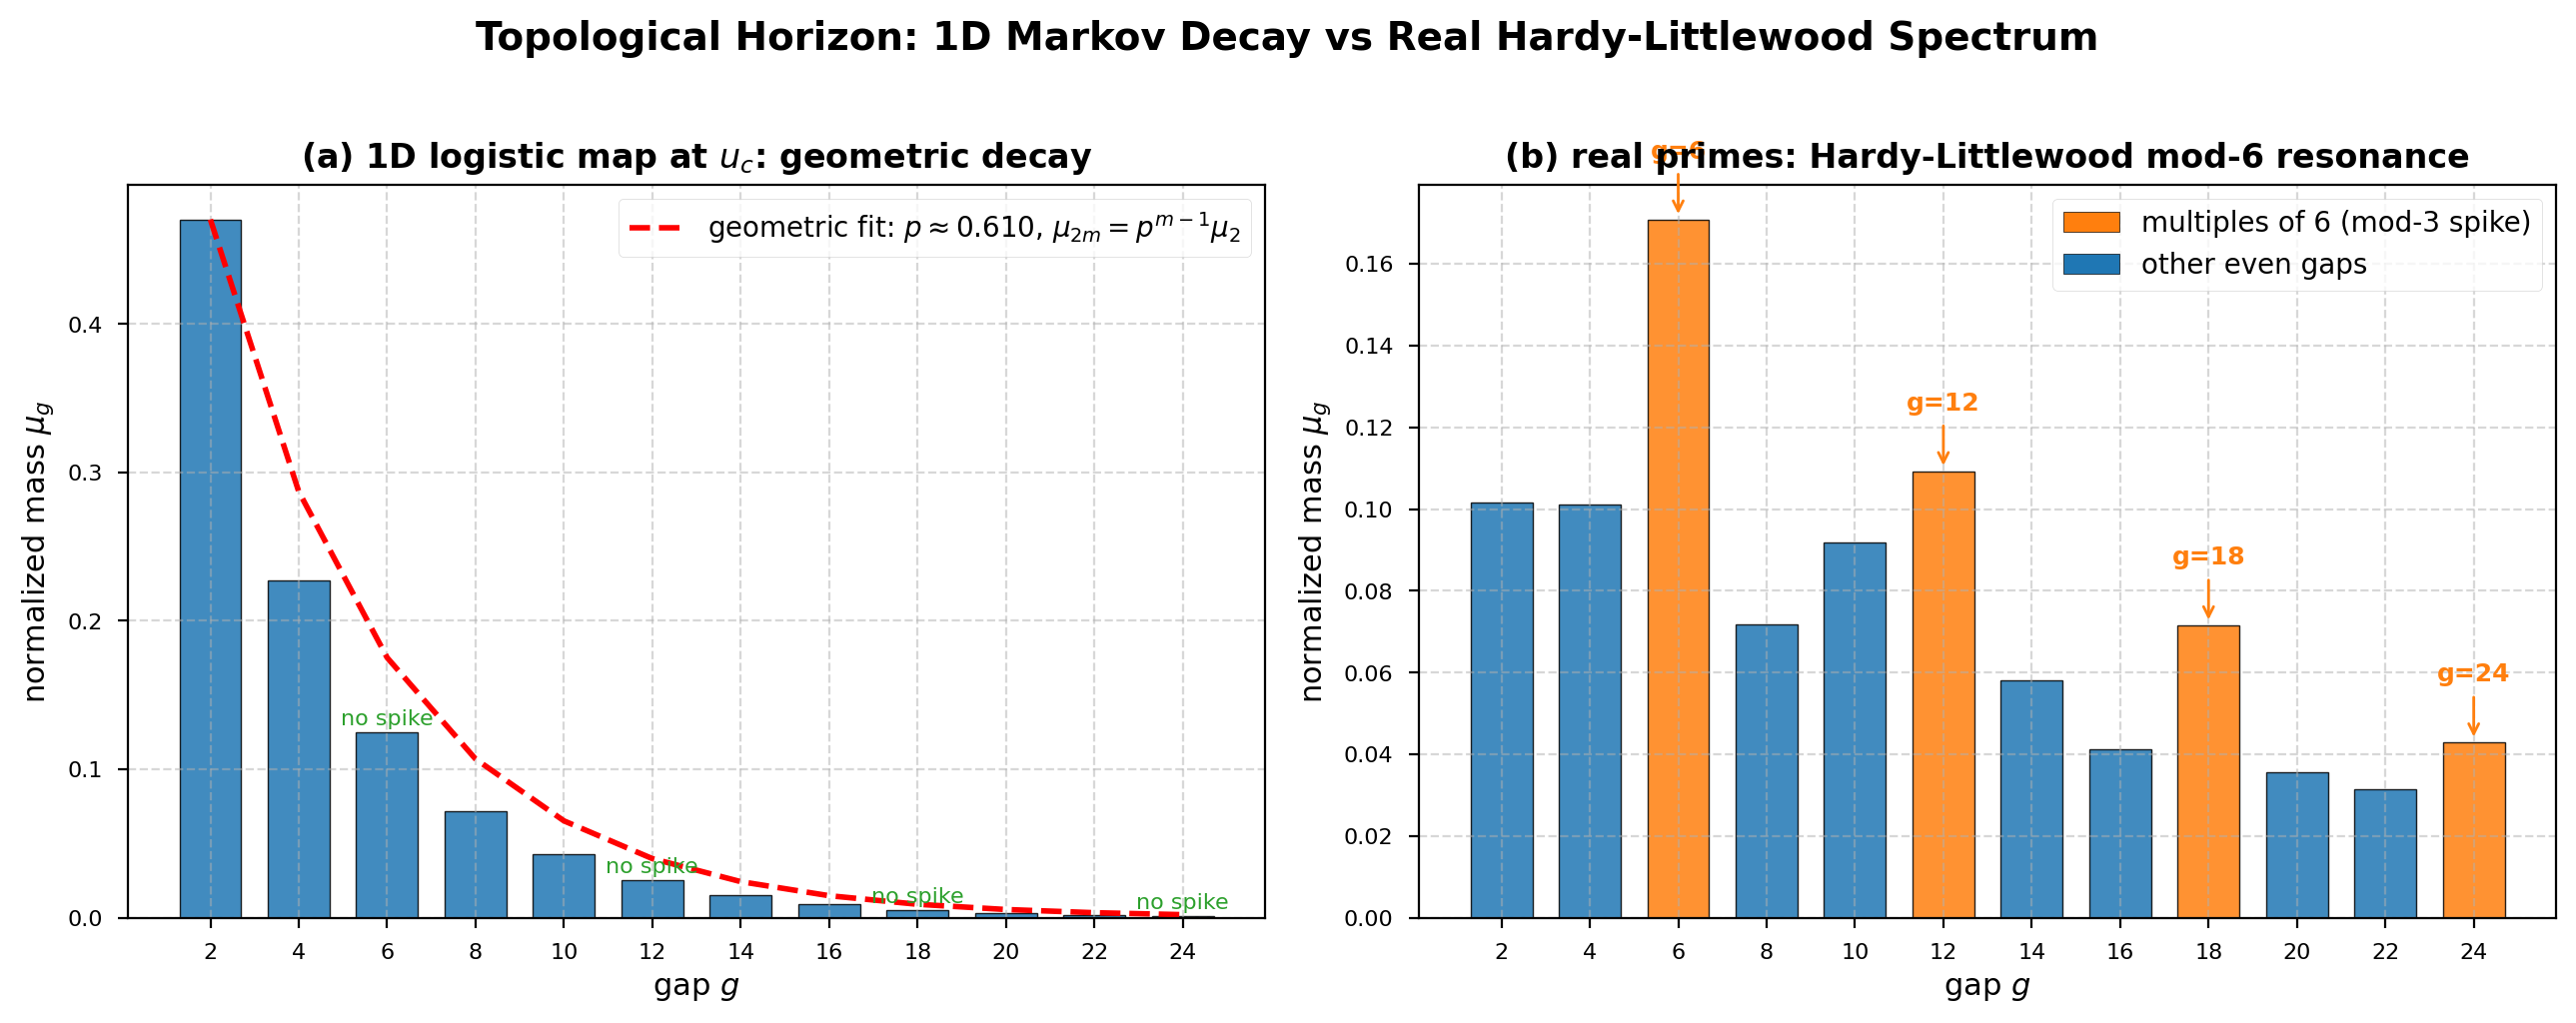

In [5]:
from IPython.display import Image, display
fig_path = ROOT / "figures" / "fig2_geometric_vs_HL.png"
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    print(f"figure not found: {fig_path}")


In [6]:
# Direct measurement of alpha_n (parity-split chain check)
# Reproduces appendix exp4c table
from collections import defaultdict
gap_counts = defaultdict(int)
for g in gaps:
    gap_counts[int(g)] += 1

# alpha_n = q_n / Q_{n-1}
total = sum(gap_counts.values())
Q_prev = total
print("Depth n | q_n      | Q_{n-1}    | alpha_n = q_n/Q_{n-1}")
for n in range(1, 11):
    g = 2*n
    q_n = gap_counts.get(g, 0)
    if Q_prev > 0:
        alpha_n = q_n / Q_prev
        print(f"  {n:>3}   | {q_n:>8} | {Q_prev:>10} | {alpha_n:.4f}")
    Q_prev -= q_n
print(f"\nTheorem C predicts alpha_n -> alpha_infty ~ 0.405")


Depth n | q_n      | Q_{n-1}    | alpha_n = q_n/Q_{n-1}
    1   |   207696 |     441119 | 0.4708
    2   |   100291 |     233423 | 0.4297
    3   |    55064 |     133132 | 0.4136
    4   |    31756 |      78068 | 0.4068
    5   |    18922 |      46312 | 0.4086
    6   |    11048 |      27390 | 0.4034
    7   |     6617 |      16342 | 0.4049
    8   |     3849 |       9725 | 0.3958
    9   |     2410 |       5876 | 0.4101
   10   |     1402 |       3466 | 0.4045

Theorem C predicts alpha_n -> alpha_infty ~ 0.405
